<a href="https://colab.research.google.com/github/Tinugoyal/Exploratory-Data-Analysis/blob/main/experiment9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Dataset loaded successfully")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset loaded successfully


In [7]:
print("Number of training samples:", X_train.shape[0])
print("Number of testing samples:", X_test.shape[0])

print("Number of classes:", len(np.unique(y_train)))

print("Image dimensions:", X_train.shape[1], "x", X_train.shape[2])

print("Classes:", np.unique(y_train))

Number of training samples: 60000
Number of testing samples: 10000
Number of classes: 10
Image dimensions: 28 x 28
Classes: [0 1 2 3 4 5 6 7 8 9]


In [9]:
X_train = X_train.reshape(X_train.shape[0], 784)
X_test = X_test.reshape(X_test.shape[0], 784)

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (60000, 784)
X_test shape: (10000, 784)


In [10]:
unique_labels, label_count = np.unique(y_train, return_counts=True)

print("Unique labels:", unique_labels)
print("Number of samples per label:")

for label, count in zip(unique_labels, label_count):
    print(f"{label}: {count}")

Unique labels: [0 1 2 3 4 5 6 7 8 9]
Number of samples per label:
0: 5923
1: 6742
2: 5958
3: 6131
4: 5842
5: 5421
6: 5918
7: 6265
8: 5851
9: 5949


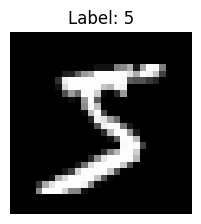

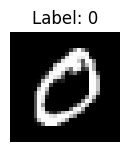

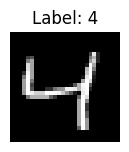

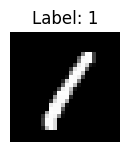

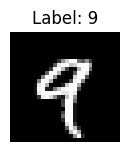

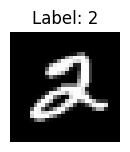

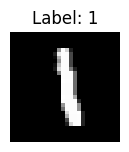

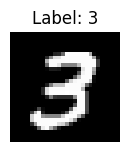

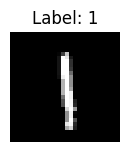

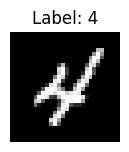

In [12]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.title("Label: " + str(y_train[i]))
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [13]:
pca_all = PCA()
pca_all.fit(X_train)

print("Number of PCA components:", len(pca_all.explained_variance_ratio_))

Number of PCA components: 784


In [15]:
for i, variance in enumerate(pca_all.explained_variance_ratio_[:20]):
      print(f"PC{i+1}: {variance:.6f}")

PC1: 0.097044
PC2: 0.070961
PC3: 0.061692
PC4: 0.053893
PC5: 0.048679
PC6: 0.043123
PC7: 0.032717
PC8: 0.028840
PC9: 0.027619
PC10: 0.023571
PC11: 0.021092
PC12: 0.020230
PC13: 0.017159
PC14: 0.016921
PC15: 0.015787
PC16: 0.014830
PC17: 0.013246
PC18: 0.012769
PC19: 0.011873
PC20: 0.011527


In [16]:
cumulative_variance = np.cumsum(pca_all.explained_variance_ratio_)

n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_99 = np.argmax(cumulative_variance >= 0.99) + 1

print("Components required for 90% variance:", n_90)
print("Components required for 95% variance:", n_95)
print("Components required for 99% variance:", n_99)

Components required for 90% variance: 87
Components required for 95% variance: 154
Components required for 99% variance: 331


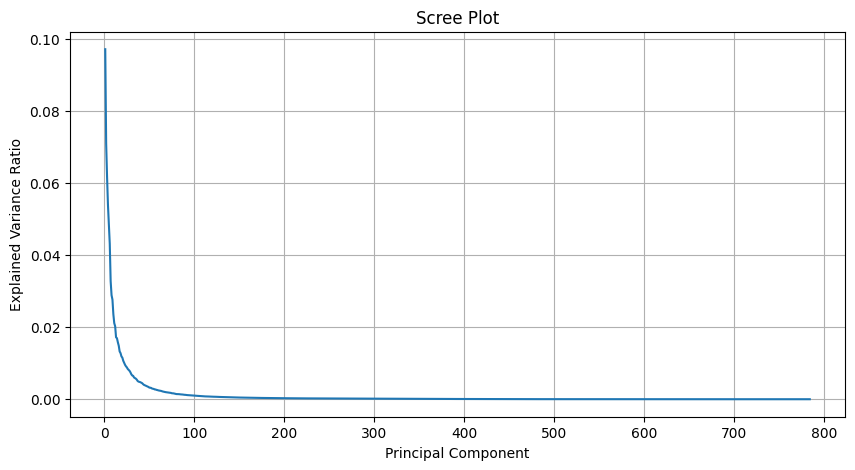

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(pca_all.explained_variance_ratio_) + 1),
        pca_all.explained_variance_ratio_
        )

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid()

plt.show()

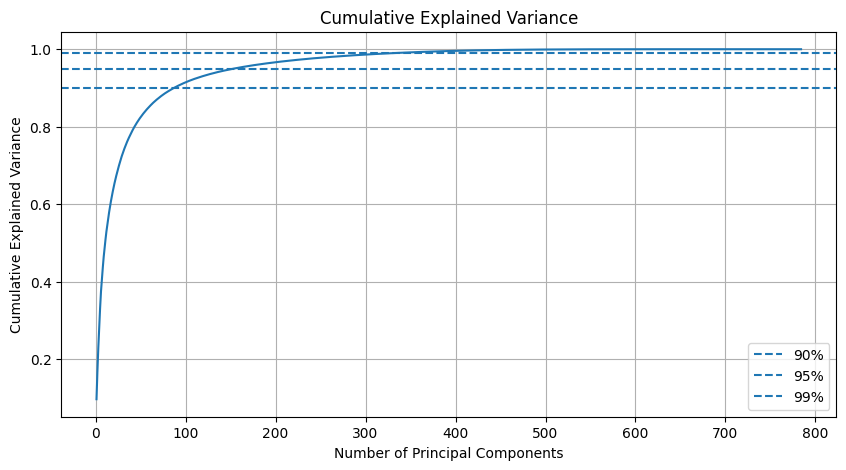

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
        cumulative_variance
        )

plt.axhline(0.90, linestyle="--", label="90%")
plt.axhline(0.95, linestyle="--", label="95%")
plt.axhline(0.99, linestyle="--", label="99%")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid()

plt.show()

In [20]:
pca_2 = PCA(n_components=2)

X_train_pca_2 = pca_2.fit_transform(X_train)
X_test_pca_2 = pca_2.transform(X_test)

print("Original dimensions:", X_train.shape[1])
print("PCA dimensions:", X_train_pca_2.shape[1])

Original dimensions: 784
PCA dimensions: 2


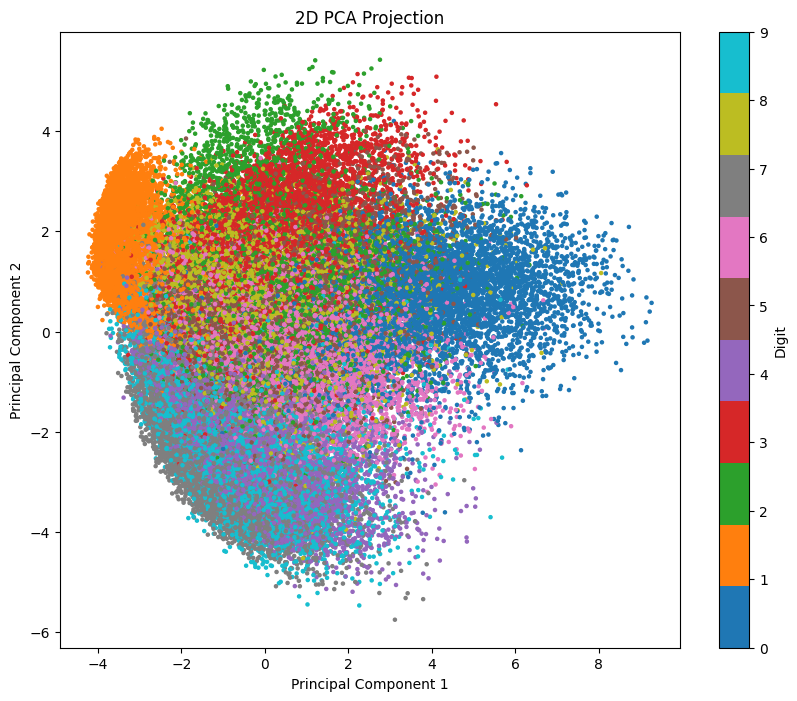

In [21]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_train_pca_2[:, 0],
    X_train_pca_2[:, 1],
    c=y_train,
    cmap="tab10",
    s=5
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection")

plt.colorbar(scatter, label="Digit")

plt.show()

In [22]:
pca_50 = PCA(n_components=50)

X_train_pca = pca_50.fit_transform(X_train)
X_test_pca = pca_50.transform(X_test)

print("Original dimensions:", X_train.shape[1])
print("PCA dimensions:", X_train_pca.shape[1])

Original dimensions: 784
PCA dimensions: 50


In [23]:
variance_50 = np.sum(pca_50.explained_variance_ratio_)

print("Variance retained by 50 components:", variance_50)

Variance retained by 50 components: 0.8246424


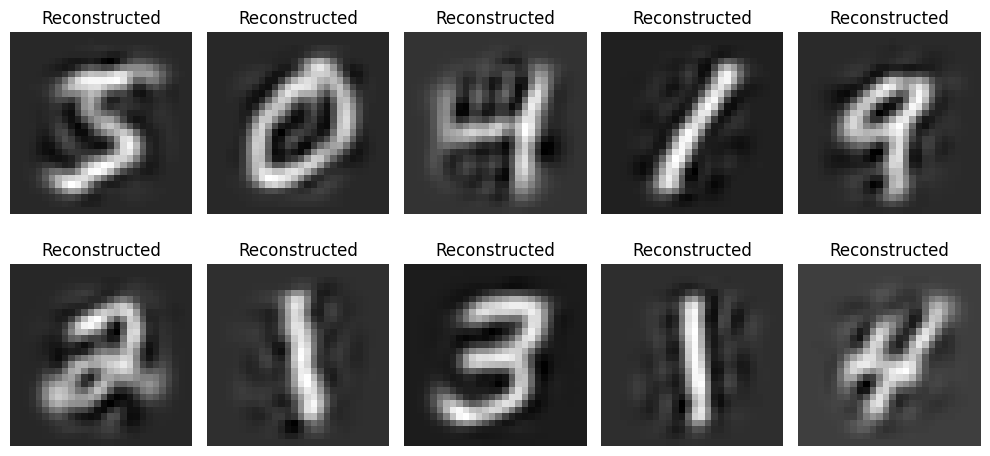

In [24]:
X_train_pca_recon = pca_50.inverse_transform(X_train_pca)

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(
                X_train_pca_recon[i].reshape(28, 28),
                        cmap="gray"
                            )

    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
N_TSNE = 5000

X_tsne_original = X_train[:N_TSNE]
y_tsne = y_train[:N_TSNE]

X_tsne_pca = X_train_pca[:N_TSNE]

print("t-SNE samples:", X_tsne_original.shape[0])

t-SNE samples: 5000


In [26]:
start_time = time.time()

tsne_original = TSNE(
    n_components=2,
        perplexity=30,
            random_state=42,
                init="random"
                )
X_tsne_original_2d = tsne_original.fit_transform(X_tsne_original)

tsne_original_time = time.time() - start_time

print("t-SNE original data completed.")
print("Time:", round(tsne_original_time, 2), "seconds")

t-SNE original data completed.
Time: 65.29 seconds


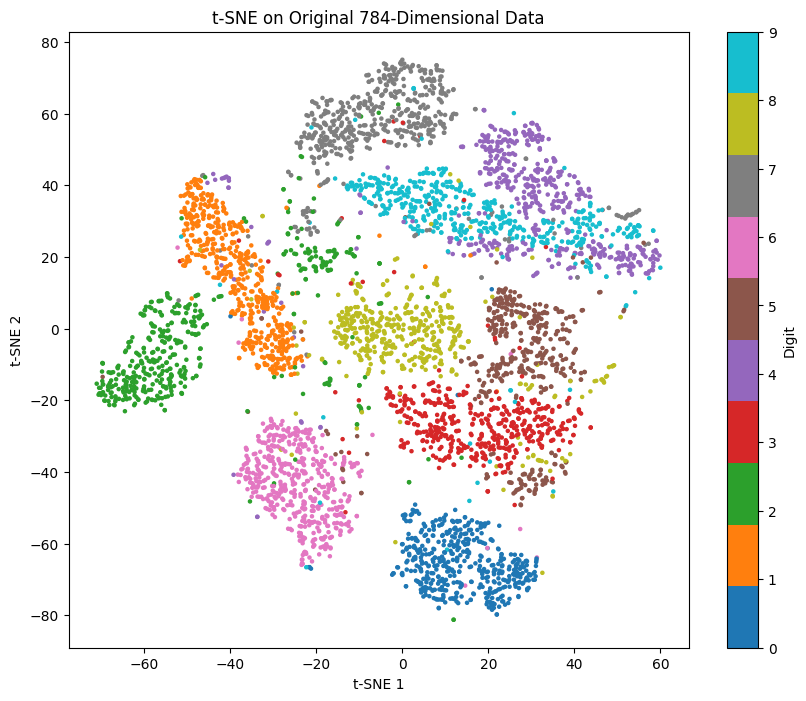

In [27]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_tsne_original_2d[:, 0],
        X_tsne_original_2d[:, 1],
            c=y_tsne,
                cmap="tab10",
                    s=5
                    )

plt.title("t-SNE on Original 784-Dimensional Data")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, label="Digit")

plt.show()


In [28]:
start_time = time.time()

tsne_pca = TSNE(
    n_components=2,
        perplexity=30,
            random_state=42,
                init="random"
                )
X_tsne_pca_2d = tsne_pca.fit_transform(X_tsne_pca)

tsne_pca_time = time.time() - start_time

print("t-SNE PCA data completed.")
print("Time:", round(tsne_pca_time, 2), "seconds")

t-SNE PCA data completed.
Time: 59.38 seconds


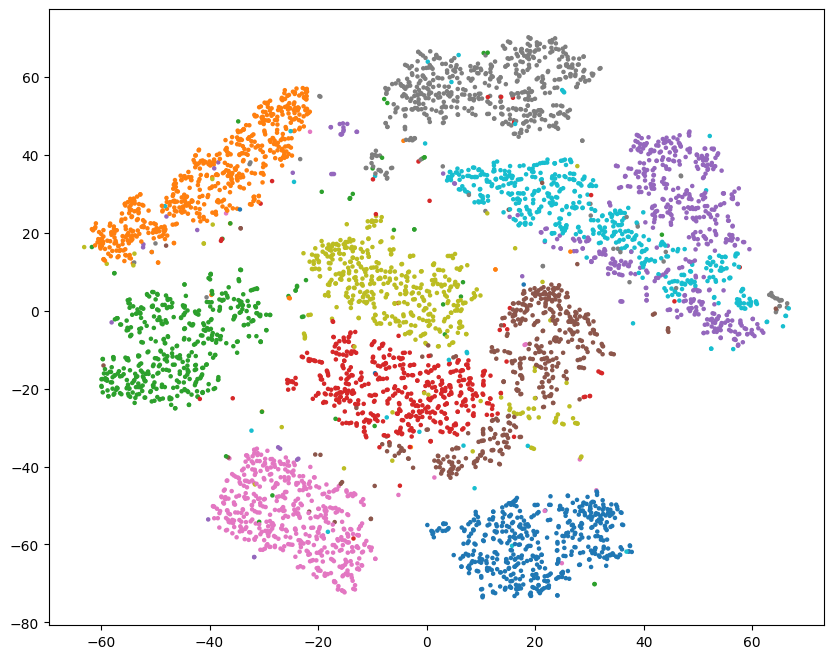

In [29]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_tsne_pca_2d[:, 0],
        X_tsne_pca_2d[:, 1],
            c=y_tsne,
                cmap="tab10",
                    s=5
                    )
plt.title("t-SNE on PCA 50-Dimensional Data")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, label="Digit")

plt.show()

Running t-SNE with perplexity = 5


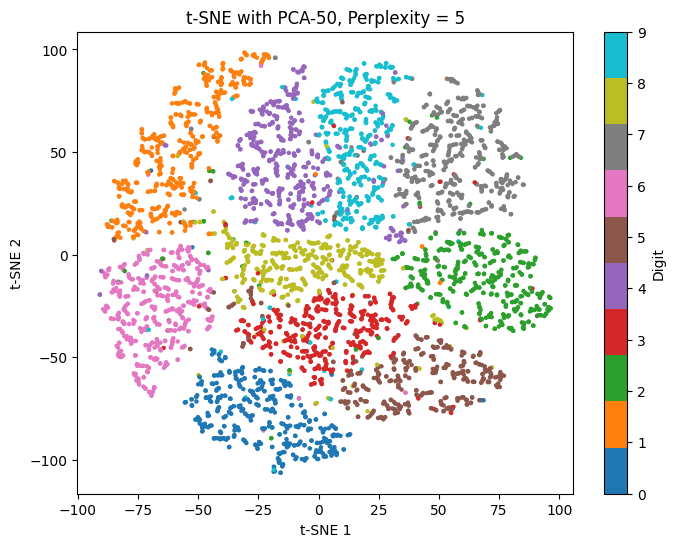

Running t-SNE with perplexity = 30


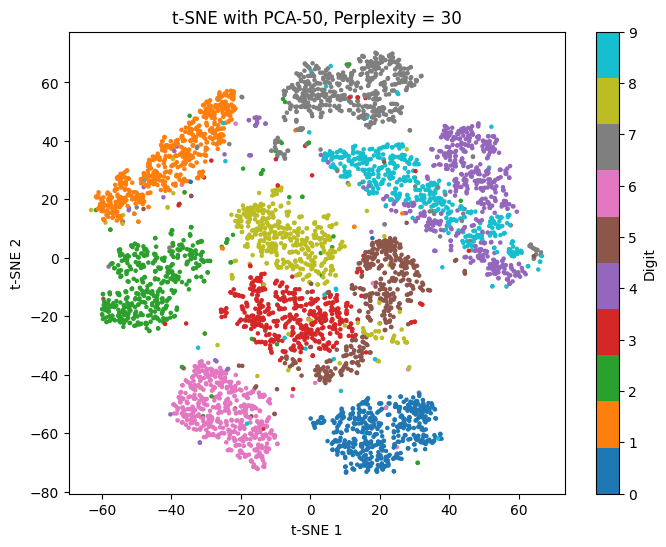

Running t-SNE with perplexity = 50


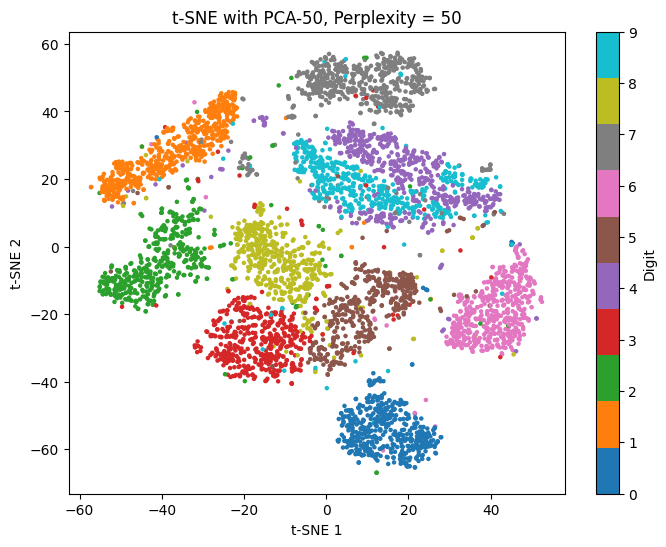

In [30]:
perplexities = [5, 30, 50]

for p in perplexities:

    print("Running t-SNE with perplexity =", p)

    tsne = TSNE(
                n_components=2,
                        perplexity=p,
                                random_state=42,
                                        init="random"
                                            )
    X_tsne = tsne.fit_transform(X_tsne_pca)

    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
                         X_tsne[:, 0],
                                 X_tsne[:, 1],
                                         c=y_tsne,
                                                 cmap="tab10",
                                                         s=5
                                                             )
    plt.title("t-SNE with PCA-50, Perplexity = " + str(p))
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.colorbar(scatter, label="Digit")

    plt.show()

In [31]:
print("Training KNN with ORIGINAL data...")

start_train = time.time()

knn_original = KNeighborsClassifier(n_neighbors=5)
knn_original.fit(X_train, y_train)

train_time_original = time.time() - start_train

start_predict = time.time()

y_pred_original = knn_original.predict(X_test)

prediction_time_original = time.time() - start_predict

accuracy_original = accuracy_score(
    y_test,
        y_pred_original
        )
print("Original Data")
print("Dimensions:", X_train.shape[1])
print("Accuracy:", accuracy_original)
print("Training Time:", train_time_original)
print("Prediction Time:", prediction_time_original)

Training KNN with ORIGINAL data...
Original Data
Dimensions: 784
Accuracy: 0.9688
Training Time: 0.04807710647583008
Prediction Time: 42.088409423828125


In [32]:
print("Training KNN with PCA data...")

start_train = time.time()

knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)

train_time_pca = time.time() - start_train

start_predict = time.time()

y_pred_pca = knn_pca.predict(X_test_pca)

prediction_time_pca = time.time() - start_predict

accuracy_pca = accuracy_score(
    y_test,
        y_pred_pca
        )
print("PCA Data")
print("Dimensions:", X_train_pca.shape[1])
print("Accuracy:", accuracy_pca)
print("Training Time:", train_time_pca)
print("Prediction Time:", prediction_time_pca)

Training KNN with PCA data...
PCA Data
Dimensions: 50
Accuracy: 0.9748
Training Time: 0.008924484252929688
Prediction Time: 4.315938472747803


In [33]:
print("Training KNN with PCA-2 data...")

start_train = time.time()

knn_pca_2 = KNeighborsClassifier(n_neighbors=5)
knn_pca_2.fit(X_train_pca_2, y_train)

train_time_pca_2 = time.time() - start_train

start_predict = time.time()

y_pred_pca_2 = knn_pca_2.predict(X_test_pca_2)

prediction_time_pca_2 = time.time() - start_predict

accuracy_pca_2 = accuracy_score(
    y_test,
        y_pred_pca_2
        )
print("PCA 2 Data")
print("Dimensions:", X_train_pca_2.shape[1])
print("Accuracy:", accuracy_pca_2)
print("Training Time:", train_time_pca_2)
print("Prediction Time:", prediction_time_pca_2)

Training KNN with PCA-2 data...
PCA 2 Data
Dimensions: 2
Accuracy: 0.4237
Training Time: 0.038962602615356445
Prediction Time: 0.045813560485839844


In [34]:
print("=" * 70)
print("PERFORMANCE COMPARISON")
print("=" * 70)

print(
    f"Original Data : {X_train.shape[1]} dimensions | "
    f"Accuracy: {accuracy_original:.4f} | "
        f"Training Time: {train_time_original:.4f}s | "
            f"Prediction Time: {prediction_time_original:.4f}s")
print(
      f"PCA-50 Data   : {X_train_pca.shape[1]} dimensions | "
          f"Accuracy: {accuracy_pca:.4f} | "
              f"Training Time: {train_time_pca:.4f}s | "
                  f"Prediction Time: {prediction_time_pca:.4f}s"
                  )

print(
                      f"PCA-2 Data    : {X_train_pca_2.shape[1]} dimensions | "
                          f"Accuracy: {accuracy_pca_2:.4f} | "
                              f"Training Time: {train_time_pca_2:.4f}s | "
                                  f"Prediction Time: {prediction_time_pca_2:.4f}s"
                                  )



PERFORMANCE COMPARISON
Original Data : 784 dimensions | Accuracy: 0.9688 | Training Time: 0.0481s | Prediction Time: 42.0884s
PCA-50 Data   : 50 dimensions | Accuracy: 0.9748 | Training Time: 0.0089s | Prediction Time: 4.3159s
PCA-2 Data    : 2 dimensions | Accuracy: 0.4237 | Training Time: 0.0390s | Prediction Time: 0.0458s


In [36]:
print("=" * 50)
print("MEMORY USAGE")
print("=" * 50)

print(
    f"Original data: "
        f"{X_train.nbytes / (1024**2):.2f} MB"
        )

print(
            f"PCA-50 data: "
                f"{X_train_pca.nbytes / (1024**2):.2f} MB"
                )

print(
                    f"PCA-2 data: "
                        f"{X_train_pca_2.nbytes / (1024**2):.2f} MB"
                        )

MEMORY USAGE
Original data: 179.44 MB
PCA-50 data: 11.44 MB
PCA-2 data: 0.46 MB


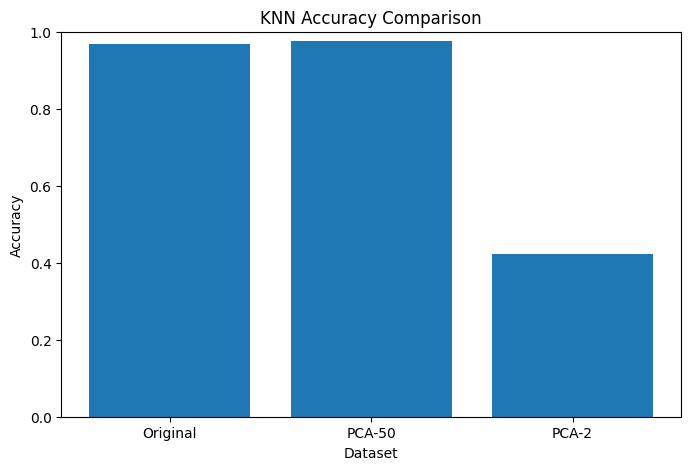

In [45]:
results = {
    "Dataset": ["Original", "PCA-50", "PCA-2"],
    "Accuracy": [accuracy_original, accuracy_pca, accuracy_pca_2]
}

plt.figure(figsize=(8, 5))

plt.bar(
    results["Dataset"],
    results["Accuracy"]
)

plt.xlabel("Dataset")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy Comparison")
plt.ylim(0, 1)

plt.show()

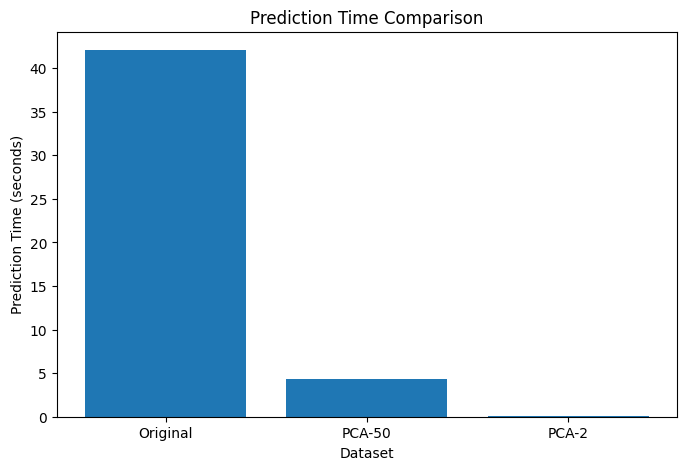

In [47]:
results["Prediction Time (s)"] = [prediction_time_original, prediction_time_pca, prediction_time_pca_2]

plt.figure(figsize=(8, 5))

plt.bar(
    results["Dataset"],
    results["Prediction Time (s)"]
)
plt.xlabel("Dataset")
plt.ylabel("Prediction Time (seconds)")
plt.title("Prediction Time Comparison")

plt.show()